This plots are designed to exactly identify which residues are holding the ligand at a specific moment in the simulaiton. By looking at the heatmap, it is possible to correlate the force spikes seen in the plots with the exact moment a residue contact breaks. 

## 1. Generate the `contacts.txt` in VMD

The script expects a file format that lists residues and their contacts over time. You can generate this running this command line arguments on the Tk Console:



In [ ]:
set target_resnames "resname ETQ"
set contact_cutoff 6.0

# Get the residues that ever come close
set sel_all [atomselect top "protein and same residue as within $contact_cutoff of $target_resnames"]
set resid_list [lsort -unique -integer [$sel_all get resid]]

set out [open "contacts.txt" w]
set num_frames [molinfo top get numframes]

puts "Calculating distances for [llength $resid_list] residues..."

foreach r $resid_list {
    set r_name_sel [atomselect top "resid $r"]
    set r_name [lindex [$r_name_sel get resname] 0]
    $r_name_sel delete
    
    puts $out "freeSelLabel $r_name $r"
    
    for {set i 0} {$i < $num_frames} {incr i} {
        # Measure the distance between Center of Mass of residue and ligand
        set res_sel [atomselect top "resid $r" frame $i]
        set lig_sel [atomselect top "$target_resnames" frame $i]
        
        # Calculate distance between centers
        set dist [vecdist [measure center $res_sel] [measure center $lig_sel]]
        
        # Record the distance
        puts $out "$i $dist"
        
        $res_sel delete
        $lig_sel delete
    }
}
close $out
puts "contacts.txt created with continuous distance values!"

# Python script to make the heatmap

Before running this python script, make sure the `contacts.txt` file is copied in the current directory

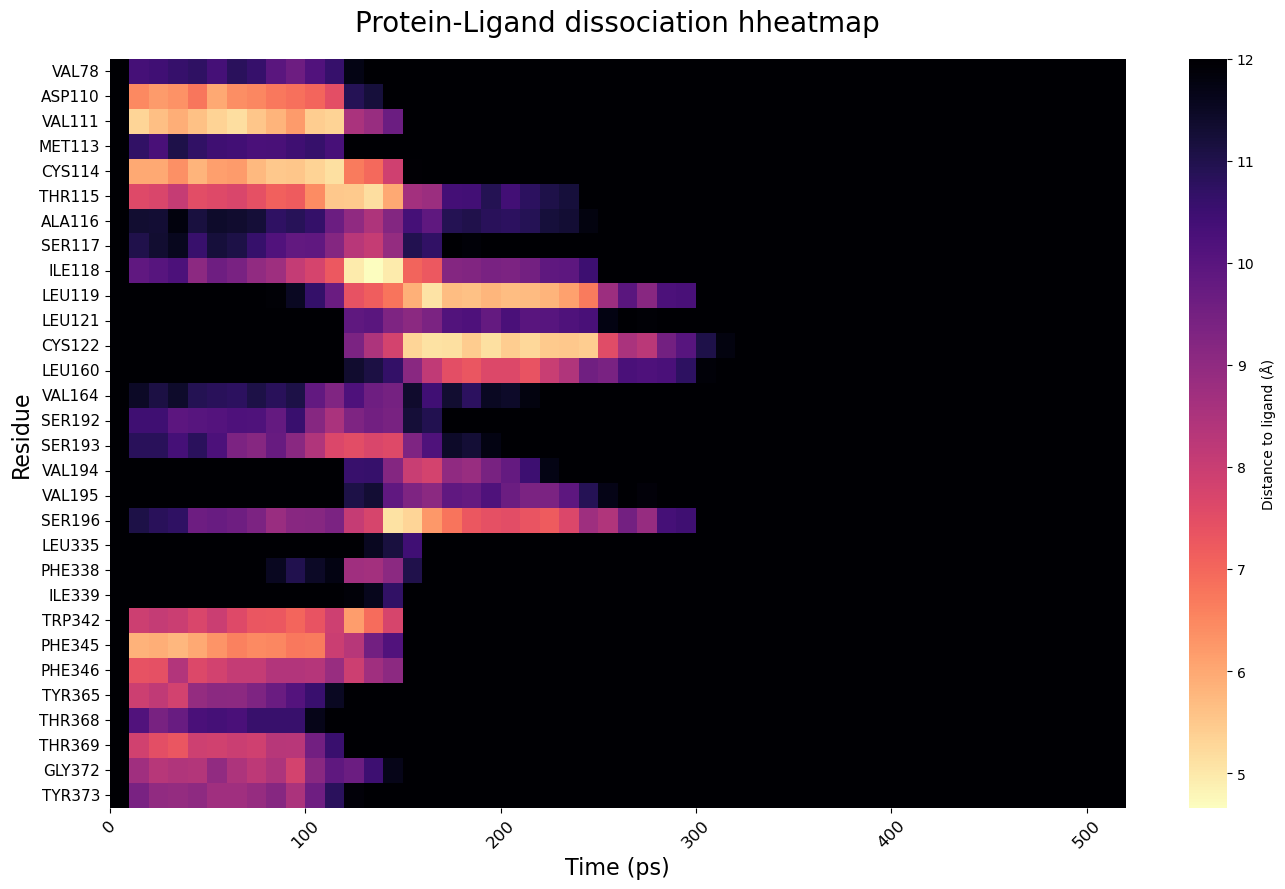

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Function to parse the distance data from your Tcl-generated contacts.txt
def parse_distances(filepath):
    with open(filepath) as f:
        content = f.read()

    # Split the file by the "freeSelLabel" markers
    blocks = re.split(r'freeSelLabel (.*?)\n', content)
    
    residue_labels = []
    distance_matrix = []

    for i in range(1, len(blocks)-1, 2):
        label = blocks[i].strip()
        data_block = blocks[i+1].strip().splitlines()

        # Clean up residue name for the Y-axis (e.g., "ILE 142")
        match = re.search(r'([A-Z]+)\s+(\d+)', label)
        if match:
            residue_labels.append(f"{match.group(1)}{match.group(2)}")
        else:
            residue_labels.append(label)

        # Extract distances as floats
        values = []
        for line in data_block:
            parts = line.strip().split()
            if len(parts) == 2:
                values.append(float(parts[1]))
        distance_matrix.append(values)

    df = pd.DataFrame(distance_matrix, index=residue_labels)
    return df

# 1. Load the data from the file you created in the Tk Console
try:
    df = parse_distances("contacts.txt")
except FileNotFoundError:
    print("Error: contacts.txt not found. Please run the Tcl script in VMD first!")

# 2. Setup the Heatmap
plt.figure(figsize=(14, 9))

# cmap="magma_r" makes CLOSE distances bright and FAR distances dark
# vmax=12 sets the limit: anything further than 12A will be dark/black
heatmap = sns.heatmap(df, 
                      cmap="magma_r", 
                      vmax=12.0, 
                      cbar_kws={'label': 'Distance to ligand (Å)'})

# 3. Formatting
plt.title("Protein-Ligand dissociation hheatmap", fontsize=20, pad=20)
plt.ylabel("Residue", fontsize=16)
plt.xlabel("Time (ps)", fontsize=16)

# Adjust X-axis labels (assuming 1 frame = 10 ps from your GROMACS pull)
ps_per_frame = 10 
xticks = range(0, df.shape[1], 10) # Label every 10th frame (100 ps)
plt.xticks(
    ticks=xticks,
    labels=[str(i * ps_per_frame) for i in xticks],
    rotation=45,
    fontsize=12
)

plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# 4. Save and Show
plt.savefig("../plots_and_pictures/ligand_unbinding_heatmap.png", dpi=300)
plt.show()